# PARA ESTE PROYECTO SOLO USAREMOS EL DF DE EGRESOS

# CARGA DE DATOS

In [1]:
import pandas as pd
import numpy as np
import missingno as sms
import seaborn as sns
import matplotlib.pyplot as plt

#pruebas estadisticas

from scipy import stats

#modelado
from sklearn.model_selection import train_test_split,cross_val_score

#modelo a usar
from xgboost import XGBClassifier

#optimizar modelo

import optuna

### CONFIGURACIONES DE LOS GRAFICOS

In [2]:
sns.set_palette('pastel')
sns.set_style('whitegrid')

### CARGA DE LOS DATOS

In [3]:
df= pd.read_csv('../datos/ssa_egresos_2023/Registros/Egresos.txt',sep='|',encoding='utf-8-sig',low_memory=False)

In [4]:
df.sample(1).T

,1764424
ID,1764425
CLUES,GRSSA004490
EGRESO,2023-01-05
INGRE,2023-01-04
DIAS_ESTA,1
TUHPSIQ,-1
SERVHC,-1
SERVHP,-1
CVEEDAD,5
EDAD,55


In [5]:
df.columns.to_list()

['ID',
 'CLUES',
 'EGRESO',
 'INGRE',
 'DIAS_ESTA',
 'TUHPSIQ',
 'SERVHC',
 'SERVHP',
 'CVEEDAD',
 'EDAD',
 'NACIOEN',
 'SEXO',
 'PESO',
 'TALLA',
 'DERHAB',
 'ENTIDAD',
 'MUNIC',
 'LOC',
 'INDIGENA',
 'HABLA_LENGUA',
 'LENGUA_INDIGENA',
 'TIPSERV',
 'SERVICIOINGRE',
 'SERVICIO02',
 'SERVICIO03',
 'SERVICIOEGRE',
 'PROCED',
 'CLUESPROCED',
 'MOTEGRE',
 'CLUESREFERIDO',
 'DIAG_INI',
 'AFECPRIN',
 'VEZ',
 'INFEC',
 'CAUSAEXT',
 'MES_ESTADISTICO',
 'ESTADO_CONYUGAL_KEY',
 'MP',
 'GESTAS',
 'PARTOS',
 'ABORTOS',
 'HAYPROD',
 'TIPATEN',
 'GESTAC',
 'PRODUCTO',
 'TIPNACI',
 'PLANFAM',
 'CESAREAS',
 'TOTAL_PRODUCTOS']

## ELIMINAR COLUMNAS QUE NO APORTAN

YA QUE ALGUNAS COLUMANS SON PARA EMBARAZOS LAS ELIMINARE 

In [6]:
df.drop(['GESTAS', 'PARTOS', 'ABORTOS', 'CESAREAS','HAYPROD', 'PRODUCTO', 'TIPNACI', 'TOTAL_PRODUCTOS','TIPATEN', 'GESTAC','MP', 'PLANFAM','ID'],axis=1,inplace=True)

primero veremos que tan mal estamos de nulos, quizas podemos eliminar alguna de primeras y borrar filas

In [7]:
pc_nulos = round(df.isna().sum()/len(df),2)
df.drop(pc_nulos.loc[pc_nulos>0.90].index.to_list(),axis=1,inplace=True)

leyendo la documentacion vemos que algunos valores son para nulos entonces aplicamos la transformacion

In [8]:
df['SEXO'] = df['SEXO'].replace({0: np.nan, 9: np.nan})
df['DERHAB'] = df['DERHAB'].replace({'0': np.nan})
df['PESO'] = df['PESO'].replace({999.0: np.nan})
df['TALLA'] = df['TALLA'].replace({999: np.nan})
df['PROCED'] = df['PROCED'].replace({9: np.nan})
df['VEZ'] = df['VEZ'].replace({9: np.nan})
df['CVEEDAD'] = df['CVEEDAD'].replace({9: np.nan})
df['EDAD'] = df['EDAD'].replace({999: np.nan})
df['INFEC'] = df['INFEC'].replace({9: np.nan})  # deja el 8 aparte por ahora

# VISTA RAPIDA DE NULOS CON MISSINGNO

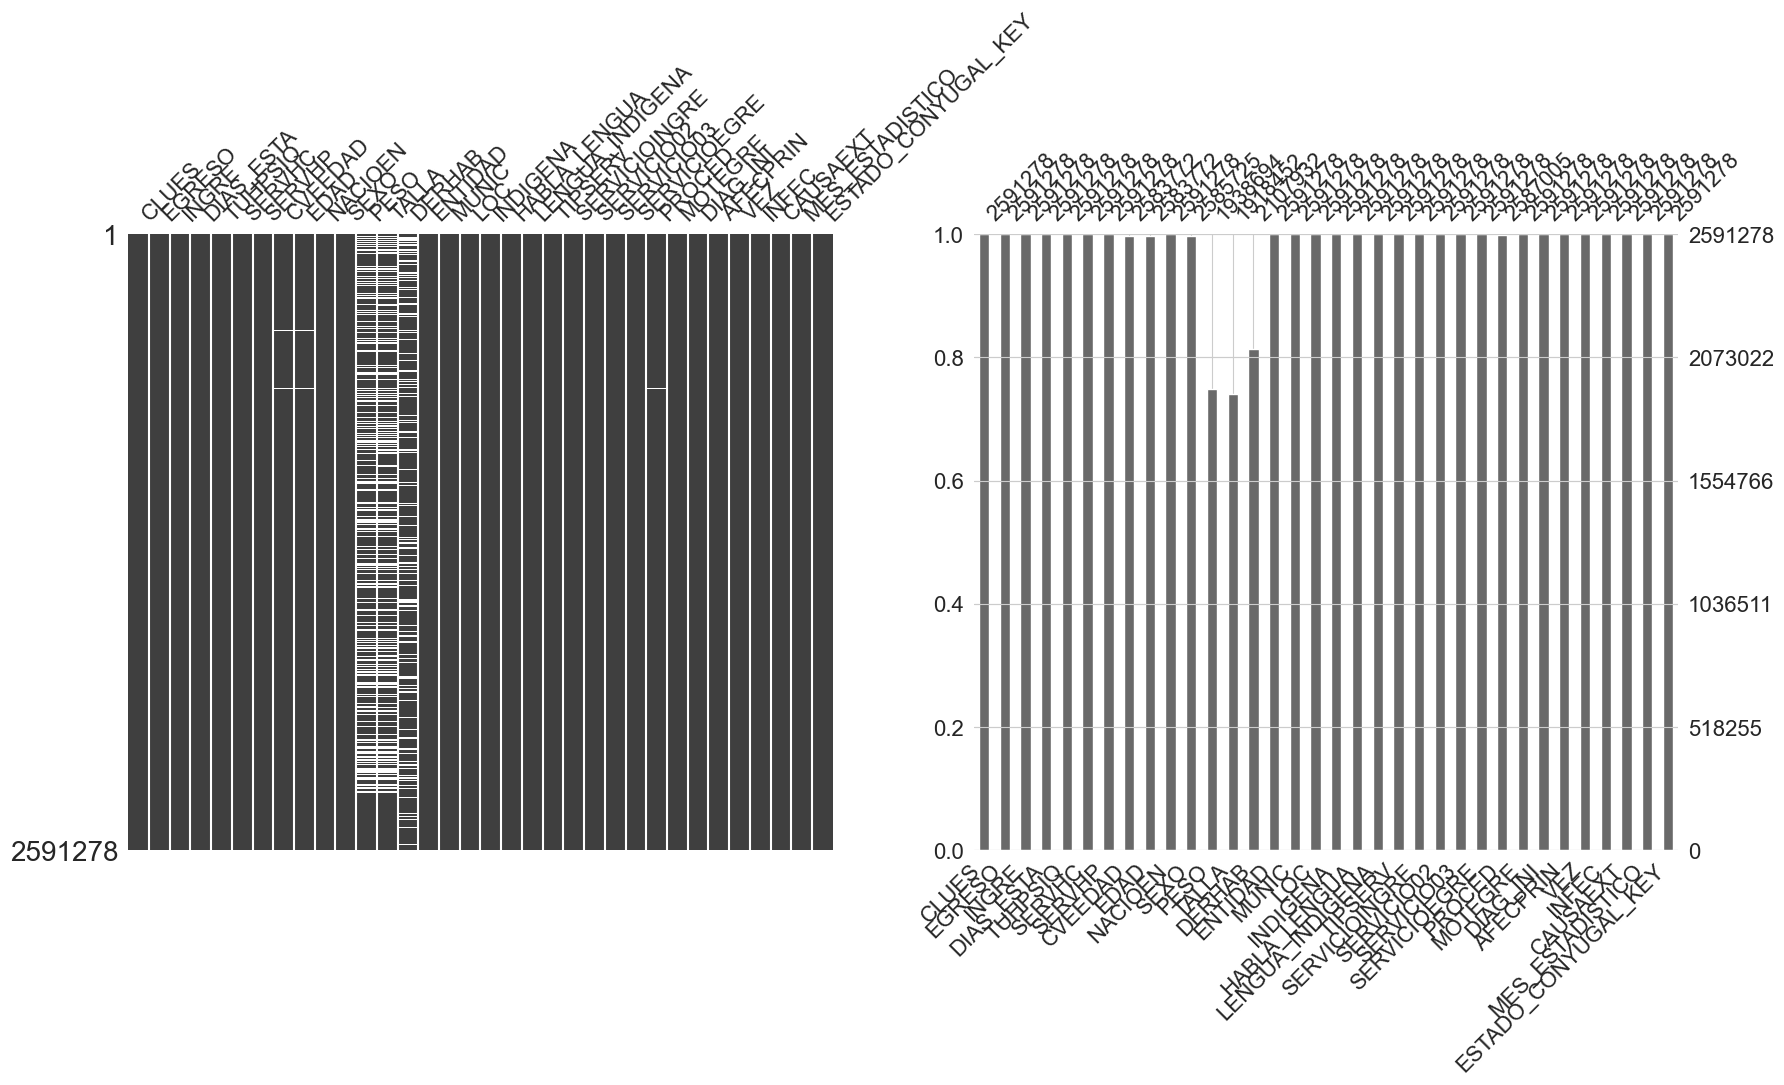

In [9]:
fig,ax = plt.subplots(1,2,figsize = (20,8))
sms.matrix(df,sparkline=False,ax=ax[0])
sms.bar(df,ax=ax[1])
plt.tight_layout
plt.show()

muchisimos nulos en talla y peso

In [10]:
pc_nulos = round(df.isna().sum()/len(df),4)
pc_nulos

CLUES                  0.0000
EGRESO                 0.0000
INGRE                  0.0000
DIAS_ESTA              0.0000
TUHPSIQ                0.0000
SERVHC                 0.0000
SERVHP                 0.0000
CVEEDAD                0.0029
EDAD                   0.0029
NACIOEN                0.0000
SEXO                   0.0021
PESO                   0.2518
TALLA                  0.2597
DERHAB                 0.1865
ENTIDAD                0.0000
MUNIC                  0.0000
LOC                    0.0000
INDIGENA               0.0000
HABLA_LENGUA           0.0000
LENGUA_INDIGENA        0.0000
TIPSERV                0.0000
SERVICIOINGRE          0.0000
SERVICIO02             0.0000
SERVICIO03             0.0000
SERVICIOEGRE           0.0000
PROCED                 0.0016
MOTEGRE                0.0000
DIAG_INI               0.0000
AFECPRIN               0.0000
VEZ                    0.0000
INFEC                  0.0000
CAUSAEXT               0.0000
MES_ESTADISTICO        0.0000
ESTADO_CON

In [11]:
#funcion crammers v

def crammers_v(crosstab):
    chi2,p,dof,expect = stats.chi2_contingency(crosstab)
    n = crosstab.sum().sum()
    r,c = crosstab.shape
    if min(r-1,c-1) == 0:
        v=0.0
    else:
        v = np.sqrt(chi2/(n*(min(r-1,c-1))))
    return v , p 

creamos las nuevas columnas para comparar

In [12]:
df['PESO_nulo'] = df['PESO'].isnull().astype(int)
df['TALLA_nulo'] = df['TALLA'].isnull().astype(int)
df['DERHAB_nulo'] = df['DERHAB'].isnull().astype(int)

haremos un test chi2 con crammer para ver el effect size y saber en que variables si hay un cambio notorio y hacer alguna hipotesis

In [13]:
resultados = []

columns_nul = ['PESO_nulo','TALLA_nulo','DERHAB_nulo']
for nul in columns_nul:
    for col in df.columns:
        if nul!=col and col not in columns_nul:
            table = pd.crosstab(df[nul],df[col])
            v,p = crammers_v(table)
            resultados.append({
                'Variable_Nula': nul,
                'Variable_Comparada': col,
                'V_Cramer': v,
                'Valor_p': p
            })
        
df_resultados_nulos = pd.DataFrame(resultados)

In [14]:
variables_peso_nulos = df_resultados_nulos[df_resultados_nulos['Variable_Nula']=='PESO_nulo'].sort_values(ascending=False,by='V_Cramer').head(20)
variables_talla_nulos =df_resultados_nulos[df_resultados_nulos['Variable_Nula']=='TALLA_nulo'].sort_values(ascending=False,by='V_Cramer').head(20)
variables_derhab_nulos = df_resultados_nulos[df_resultados_nulos['Variable_Nula']=='DERHAB_nulo'].sort_values(ascending=False,by='V_Cramer').head(20)

matriz_nulos_num = df.corr(numeric_only=True,method='spearman')[columns_nul]


In [15]:
variables_derhab_nulos

,Variable_Nula,Variable_Comparada,V_Cramer,Valor_p
68,DERHAB_nulo,CLUES,0.641321,0.0
82,DERHAB_nulo,ENTIDAD,0.242773,0.0
83,DERHAB_nulo,MUNIC,0.221352,0.0
96,DERHAB_nulo,AFECPRIN,0.172338,0.0
95,DERHAB_nulo,DIAG_INI,0.172075,0.0
89,DERHAB_nulo,SERVICIOINGRE,0.152596,0.0
92,DERHAB_nulo,SERVICIOEGRE,0.150998,0.0
101,DERHAB_nulo,ESTADO_CONYUGAL_KEY,0.149525,0.0
90,DERHAB_nulo,SERVICIO02,0.147180,0.0
79,DERHAB_nulo,PESO,0.108743,0.0


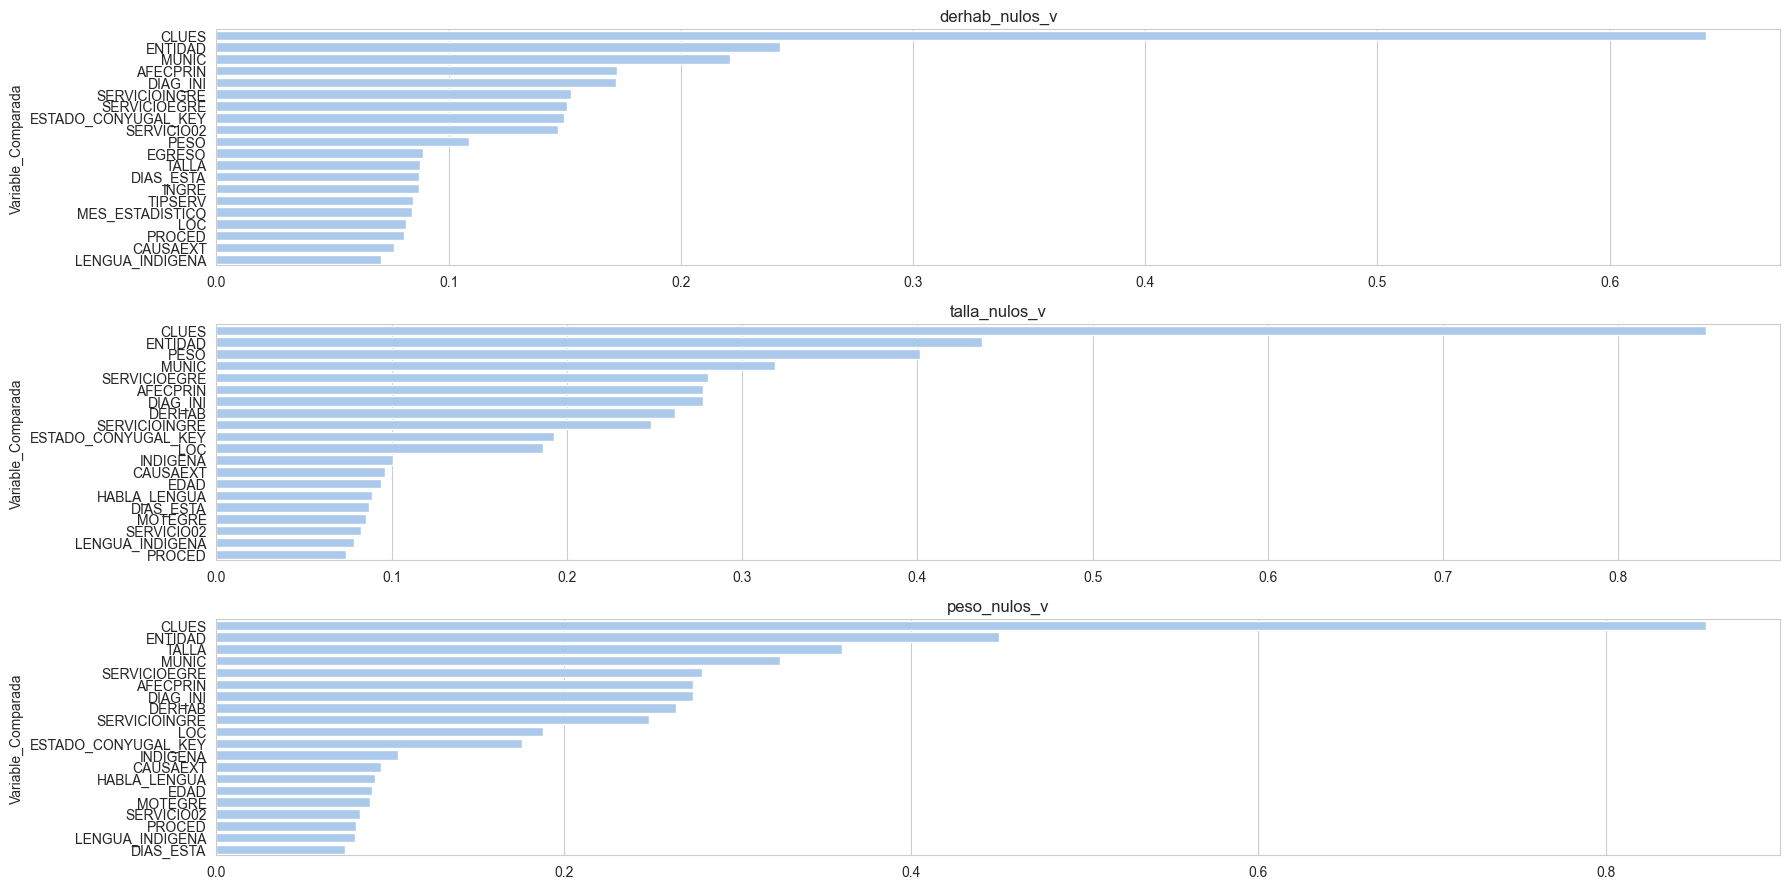

In [16]:
fig,ax = plt.subplots(3,1,figsize = (18,9))
ax[0].set_title('derhab_nulos_v')
sns.barplot(x=variables_derhab_nulos['V_Cramer'].values,y=variables_derhab_nulos['Variable_Comparada'],ax=ax[0])
ax[1].set_title('talla_nulos_v')
sns.barplot(x=variables_talla_nulos['V_Cramer'].values,y=variables_talla_nulos['Variable_Comparada'],ax=ax[1])
ax[2].set_title('peso_nulos_v')
sns.barplot(x=variables_peso_nulos['V_Cramer'].values,y=variables_peso_nulos['Variable_Comparada'],ax=ax[2])

plt.tight_layout()
plt.show()

<Axes: >

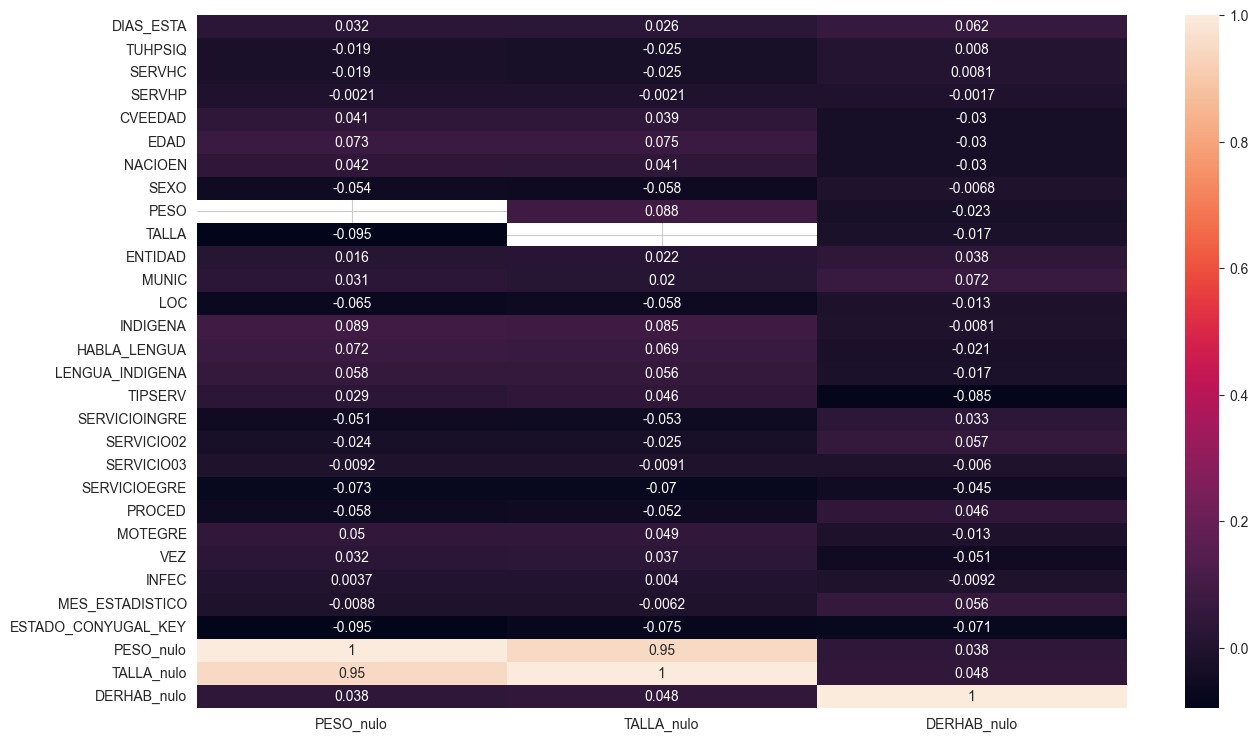

In [17]:
plt.figure(figsize=(15,9))
sns.heatmap(matriz_nulos_num,annot=True)

como podemos ver la falta de valores es institucional o esa es mi toeria, algunos hospitales no capturas estos datos como otros sin emabrgo hay una relacion menos fuerte en lo clinico pero menos fuerte, algunas especialidades podria no importarle tanto anotar esos datos

confirmemos la teoria para talla y peso, como vimos en la matriz hay redudancia, cuando no anotan en talla tampoco en peso y viceversa entonces solo buscaremos en talla

<Axes: title={'center': 'hospitales donde importa muy poco la derechohabiencia: 20'}, ylabel='CLUES'>

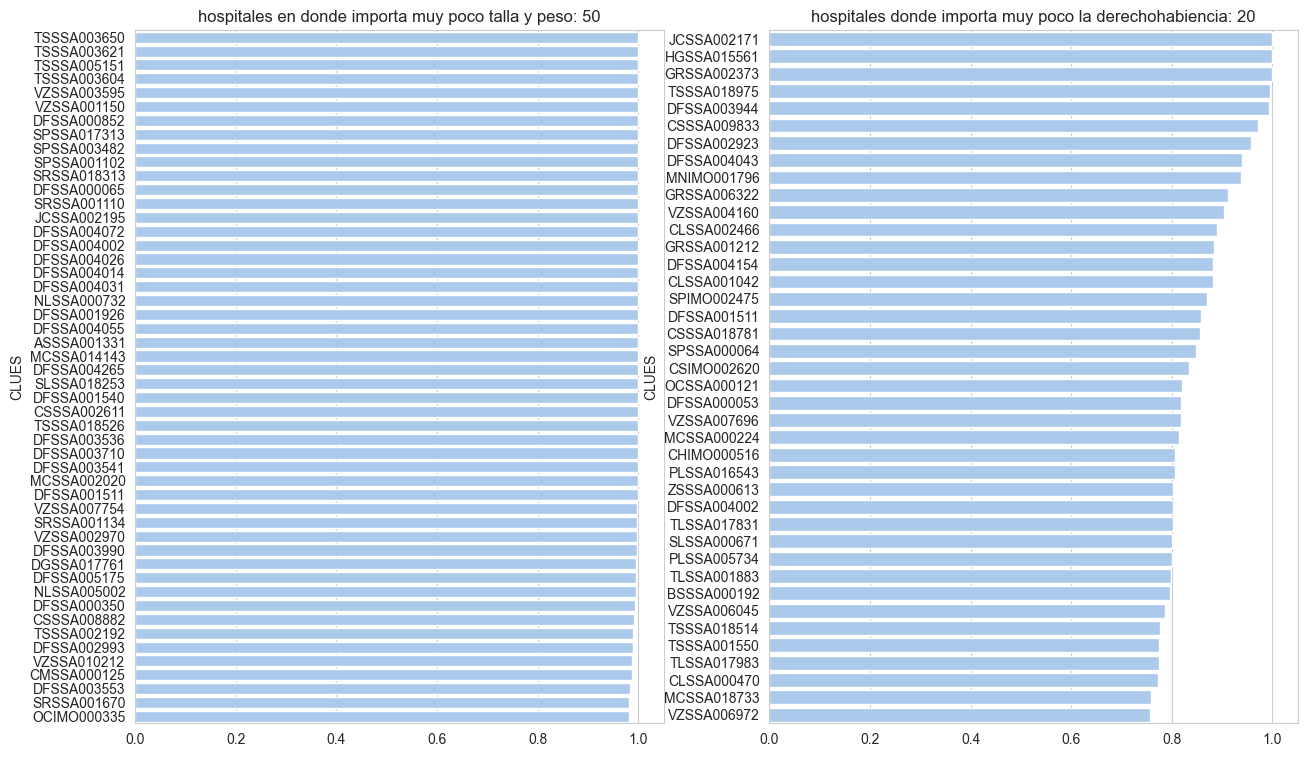

In [18]:
talla_edad_clues=df.groupby('CLUES')['TALLA_nulo'].mean().sort_values(ascending=False).head(50)
derhab_clues =df.groupby('CLUES')['DERHAB_nulo'].mean().sort_values(ascending=False).head(40)
fig,ax = plt.subplots(1,2,figsize = (15,9))
ax[0].set_title('hospitales en donde importa muy poco talla y peso: 50')
sns.barplot(x=talla_edad_clues.values,y=talla_edad_clues.index,ax=ax[0])
ax[1].set_title('hospitales donde importa muy poco la derechohabiencia: 20')
sns.barplot(x=derhab_clues.values,y=derhab_clues.index,ax=ax[1])

si,podemos ver que en algunos hospitales inclusive no han anotado ningun registro, esto es algo peligroso pero no entraremos en detalles en este analisis

veremos la segunda parte, la relacion en base al servicio de ingreso ya que podemos ver que en algunos lugares no se toma

<Axes: title={'center': 'areas donde importa muy poco la derechohabiencia: 20'}, ylabel='SERVICIOINGRE'>

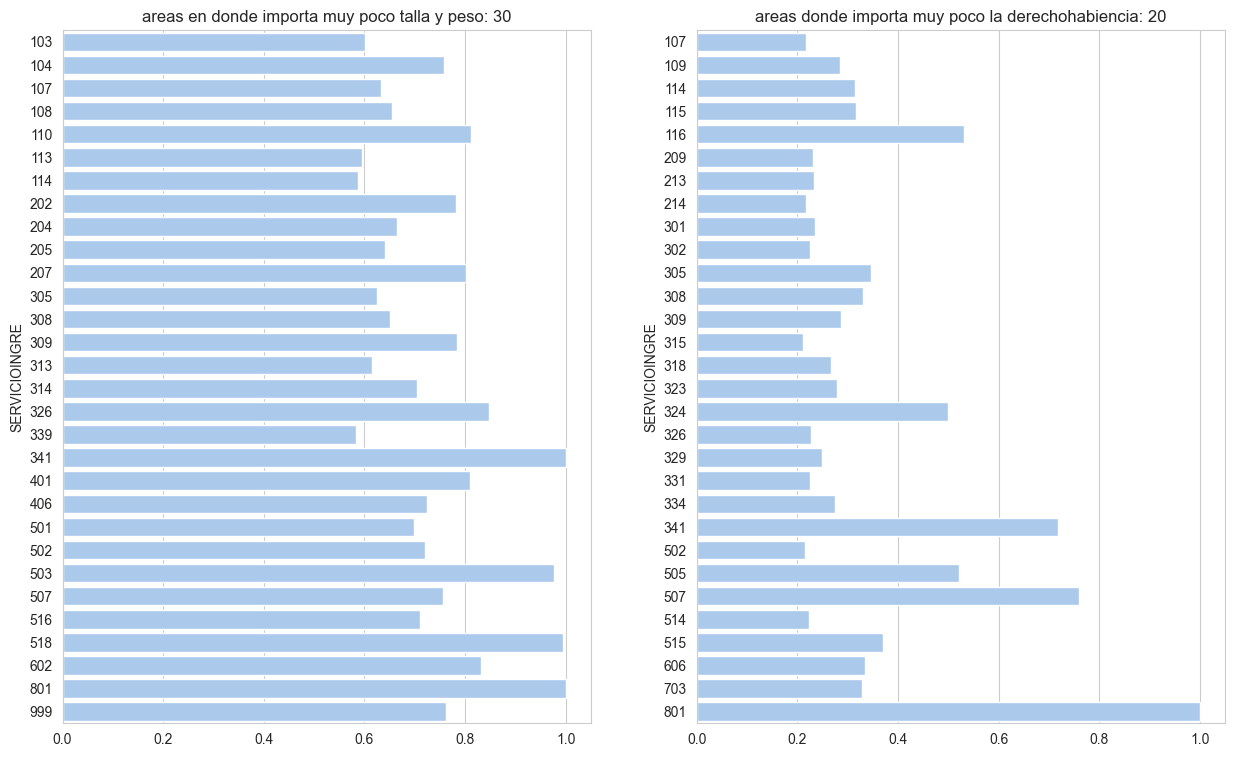

In [19]:
servicio_talla_na = df.groupby('SERVICIOINGRE')['TALLA_nulo'].mean().sort_values(ascending=False).head(30)
servicio_derha_na =df.groupby('SERVICIOINGRE')['DERHAB_nulo'].mean().sort_values(ascending=False).head(30)
fig,ax = plt.subplots(1,2,figsize = (15,9))
ax[0].set_title('areas en donde importa muy poco talla y peso: 30')
sns.barplot(x=servicio_talla_na.values,y=servicio_talla_na.index,ax=ax[0],orient='h')
ax[1].set_title('areas donde importa muy poco la derechohabiencia: 20')
sns.barplot(x=servicio_derha_na.values,y=servicio_derha_na.index,ax=ax[1],orient='h')

CONCLUSION DE LA INVESTIGACION DE VALORES NULOS

El análisis de missingness reveló que la ausencia de peso/talla y derechohabiencia no es aleatoria (MCAR) ni depende principalmente de las características clínicas del paciente, sino que está determinada por la institución de captura (CLUES) y el servicio de ingreso — algunos hospitales presentan tasas de no-captura cercanas al 100%, sugiriendo diferencias sistemáticas en protocolos de registro entre unidades médicas, más que variabilidad clínica genuina

usaremos modelos que manejan valores nulos

# EDA UNIVARIADO Y VALORES NULOS

# haremos un analizis rapido

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2591278 entries, 0 to 2591277
Data columns (total 37 columns):
 #   Column               Dtype  
---  ------               -----  
 0   CLUES                object 
 1   EGRESO               object 
 2   INGRE                object 
 3   DIAS_ESTA            int64  
 4   TUHPSIQ              int64  
 5   SERVHC               int64  
 6   SERVHP               int64  
 7   CVEEDAD              float64
 8   EDAD                 float64
 9   NACIOEN              int64  
 10  SEXO                 float64
 11  PESO                 float64
 12  TALLA                float64
 13  DERHAB               object 
 14  ENTIDAD              int64  
 15  MUNIC                int64  
 16  LOC                  int64  
 17  INDIGENA             int64  
 18  HABLA_LENGUA         int64  
 19  LENGUA_INDIGENA      int64  
 20  TIPSERV              int64  
 21  SERVICIOINGRE        int64  
 22  SERVICIO02           int64  
 23  SERVICIO03           int64  
 24

In [21]:
df=df.drop(columns_nul,axis=1)

CREAMOS NUESTRO TARGET


In [22]:
df['defuncion'] = (df['MOTEGRE'] == 5).astype(int)
df['defuncion'].value_counts(normalize=True)

defuncion
0    0.974615
1    0.025385
Name: proportion, dtype: float64

In [23]:
col_num = ['EDAD', 'DIAS_ESTA', 'PESO', 'TALLA']  
col_cat = [c for c in df.columns if c not in col_num + ['defuncion','MOTEGRE','CLUES','EGRESO','INGRE','DIAG_INI','AFECPRIN','CAUSAEXT']]
codigos_clinicos = ['DIAG_INI','AFECPRIN','CAUSAEXT']  

In [24]:
df[col_num].describe().T

,count,mean,std,min,25%,50%,75%,max
EDAD,2583772.0,34.568929,21.310640,1.0,20.0,30.0,50.0,120.0
DIAS_ESTA,2591278.0,3.773022,52.403086,0.0,1.0,2.0,3.0,15000.0
PESO,1938694.0,62.256022,25.676105,0.5,54.0,65.0,76.8,400.0
TALLA,1918452.0,145.483487,32.354902,15.0,148.0,156.0,162.0,220.0


In [25]:
df[col_cat].describe().T

,count,mean,std,min,25%,50%,75%,max
TUHPSIQ,2591278.0,-0.986087,0.166717,-1.0,-1.0,-1.0,-1.0,3.0
SERVHC,2591278.0,-0.979037,0.254935,-1.0,-1.0,-1.0,-1.0,9.0
SERVHP,2591278.0,-0.999961,0.011233,-1.0,-1.0,-1.0,-1.0,9.0
CVEEDAD,2583772.0,4.854099,0.594531,2.0,5.0,5.0,5.0,5.0
NACIOEN,2591278.0,7.624896,1.557592,1.0,8.0,8.0,8.0,8.0
SEXO,2585725.0,1.668102,0.470920,1.0,1.0,2.0,2.0,3.0
ENTIDAD,2591278.0,18.705988,14.128219,0.0,11.0,15.0,25.0,99.0
MUNIC,2591278.0,96.499999,215.120548,1.0,11.0,31.0,78.0,999.0
LOC,2591278.0,1002.626220,2959.407877,1.0,1.0,1.0,21.0,9999.0
INDIGENA,2591278.0,1.959492,0.362230,1.0,2.0,2.0,2.0,9.0


In [26]:
df[codigos_clinicos].describe().T

,count,unique,top,freq
DIAG_INI,2591278,7871,O809,286908
AFECPRIN,2591278,7953,O809,280519
CAUSAEXT,2591278,2110,8888,2373826


veamos los boxplots de nuestras numericas reales

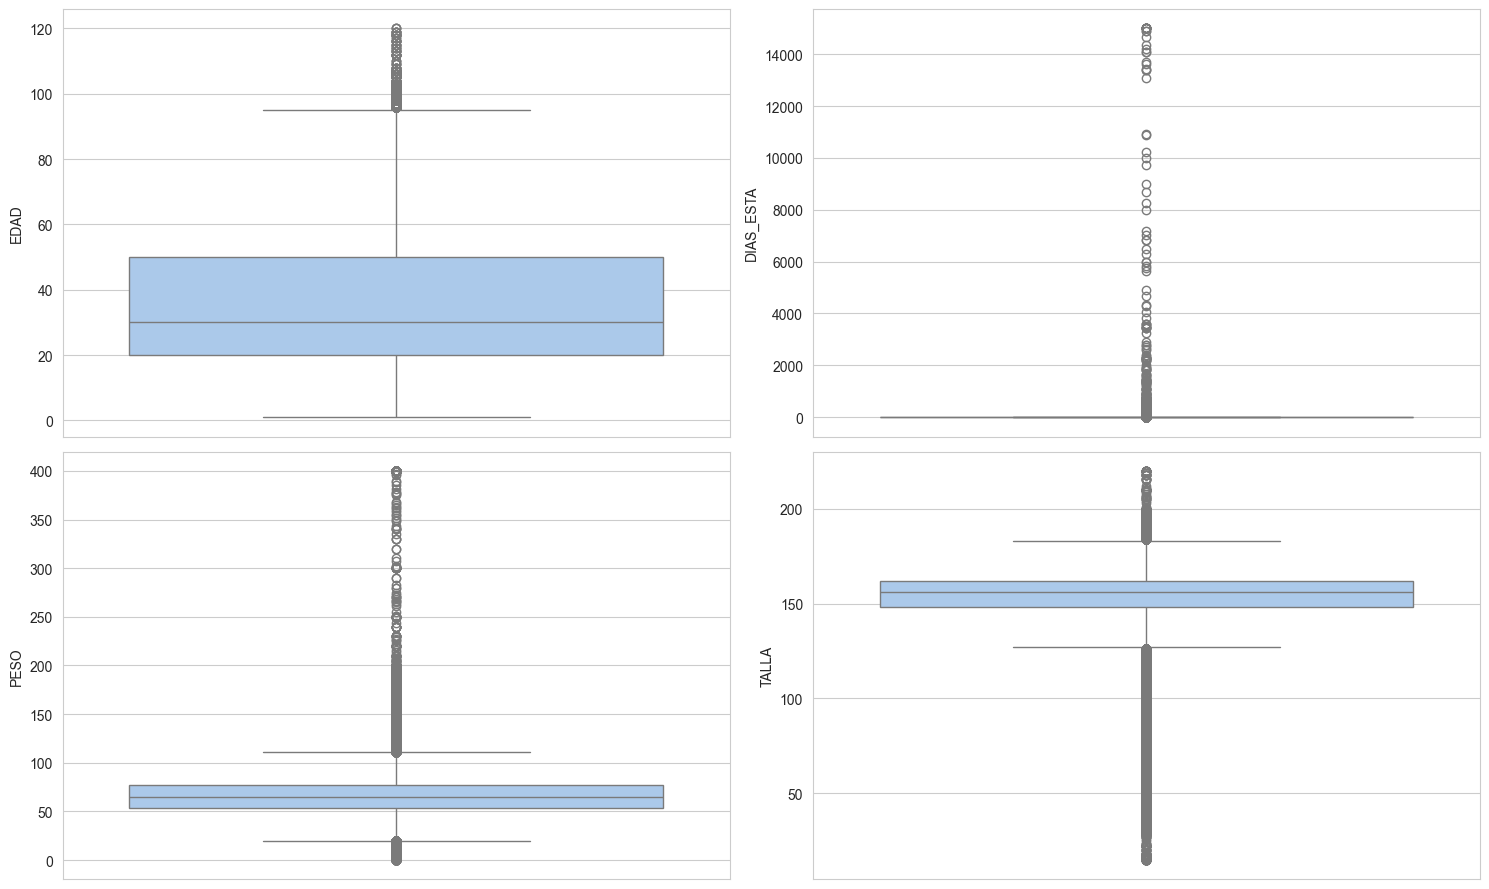

In [27]:
fig,ax = plt.subplots(2,2,figsize = (15,9))
for axes,col in zip(ax.flat,col_num):
    sns.boxplot(df[col],ax=axes)
plt.tight_layout()
plt.show()

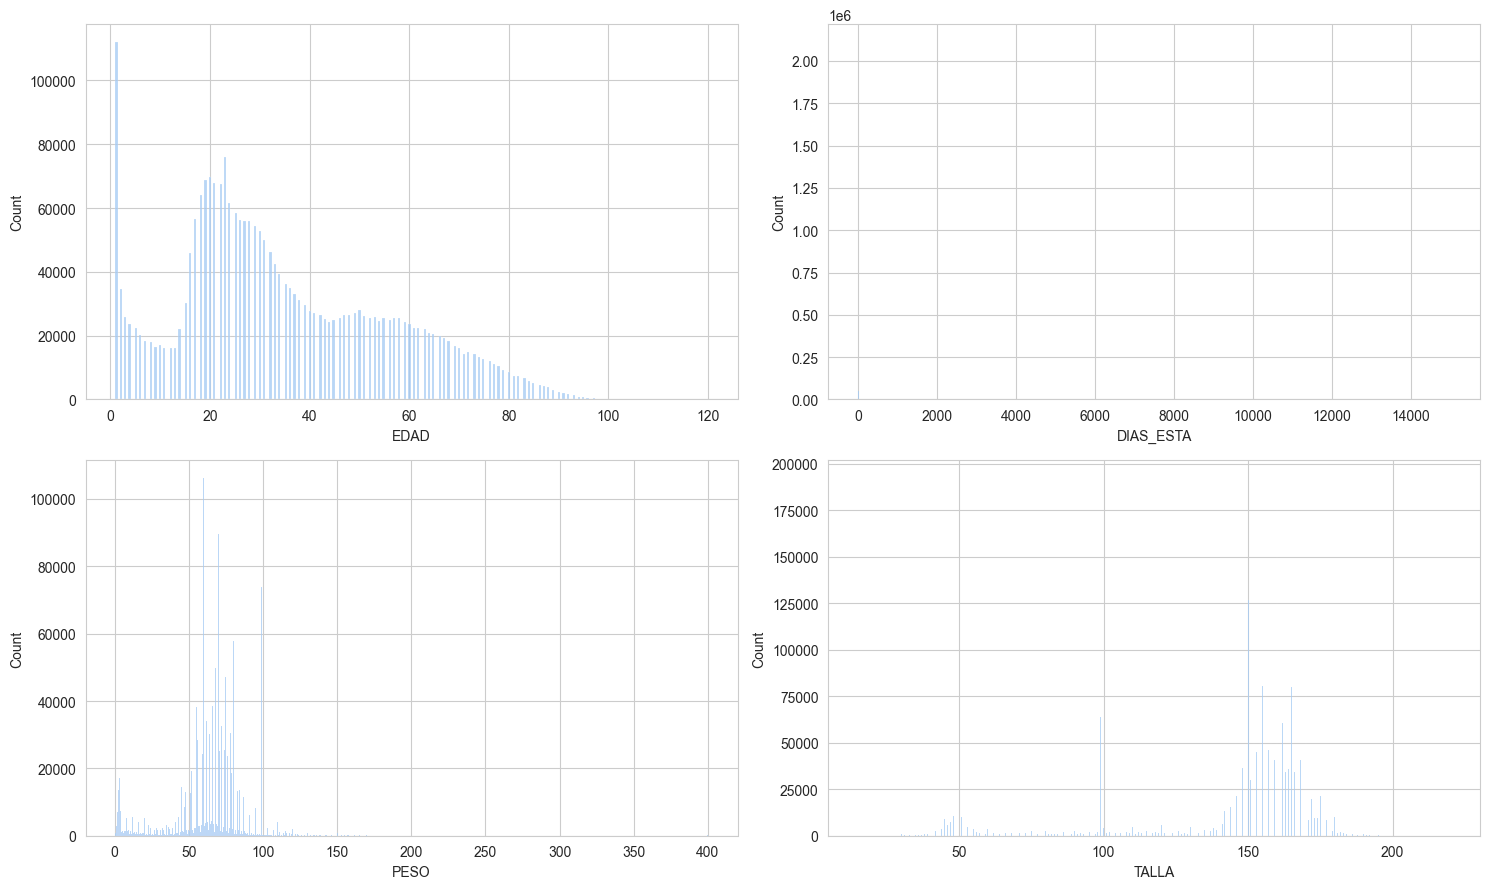

In [28]:
fig,ax = plt.subplots(2,2,figsize = (15,9))
for axes,col in zip(ax.flat,col_num):
    sns.histplot(df[col],ax=axes)
plt.tight_layout()
plt.show()

tenemos muchisimos outliers en este momento. la buena noticia es que xgboost los maneja bien, aun asi buscare una transformacion en un futuro

# ANALISIS BIVARIADO

<Axes: >

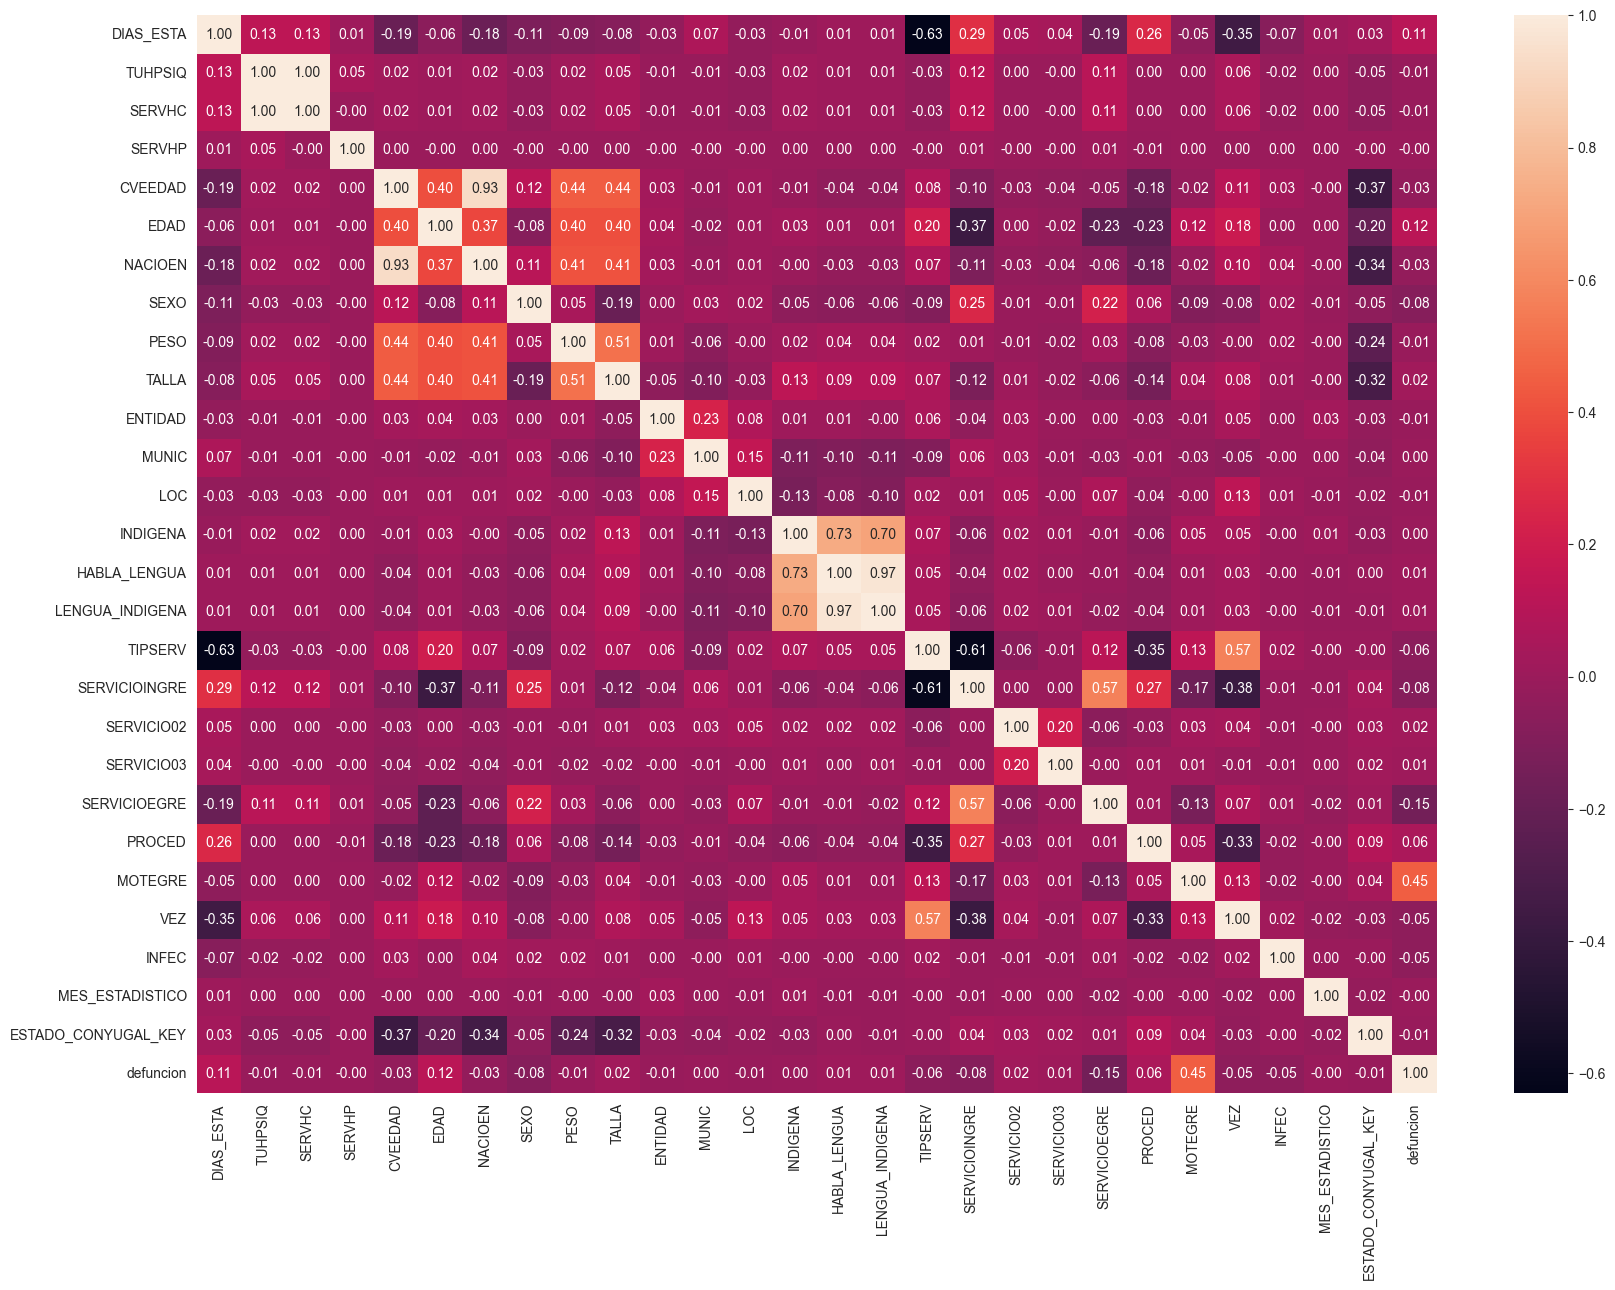

In [29]:
plt.figure(figsize=(20,14))
sns.heatmap(round(df.corr(numeric_only=True,method='spearman'),2),fmt='.2f',annot=True)

In [30]:
results = []
for col in col_cat:
    v_u = df[col].nunique()
    results.append({
        'variable': col,
        'valores_unicos' : v_u
    })
    
results_nu = pd.DataFrame(results)
results_nu.sort_values(ascending=False,by='valores_unicos')

,variable,valores_unicos
9,LOC,2160
8,MUNIC,573
17,SERVICIOEGRE,111
14,SERVICIOINGRE,110
15,SERVICIO02,101
12,LENGUA_INDIGENA,89
16,SERVICIO03,72
7,ENTIDAD,35
21,MES_ESTADISTICO,12
6,DERHAB,12


veamos la fuerza de cada variale contra el target

In [31]:
vstarg = []
for col in col_cat:

        table = pd.crosstab(df[col],df['defuncion'])
        v,p = crammers_v(table)
        vstarg.append({
            'columna': col,
            'fuerza' : v,
            'p-value' : p
        })
        
df_vstarg = pd.DataFrame(vstarg)

In [32]:
df_vstarg.sort_values(ascending=False,by='fuerza')

,columna,fuerza,p-value
17,SERVICIOEGRE,0.256914,0.000000e+00
14,SERVICIOINGRE,0.249692,0.000000e+00
5,SEXO,0.084548,0.000000e+00
22,ESTADO_CONYUGAL_KEY,0.082752,0.000000e+00
18,PROCED,0.068386,0.000000e+00
13,TIPSERV,0.059939,0.000000e+00
15,SERVICIO02,0.055795,0.000000e+00
20,INFEC,0.049918,0.000000e+00
7,ENTIDAD,0.047568,0.000000e+00
19,VEZ,0.046331,0.000000e+00


podemos ver que no hay una que sea muy fuerte, sin embargo hay algunas que podemos rescatar

C:\Users\Diego\AppData\Local\Temp\ipykernel_62448\3775456800.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=areas_top_10.values,y=[
C:\Users\Diego\AppData\Local\Temp\ipykernel_62448\3775456800.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=egreso_top_10.values, y=[


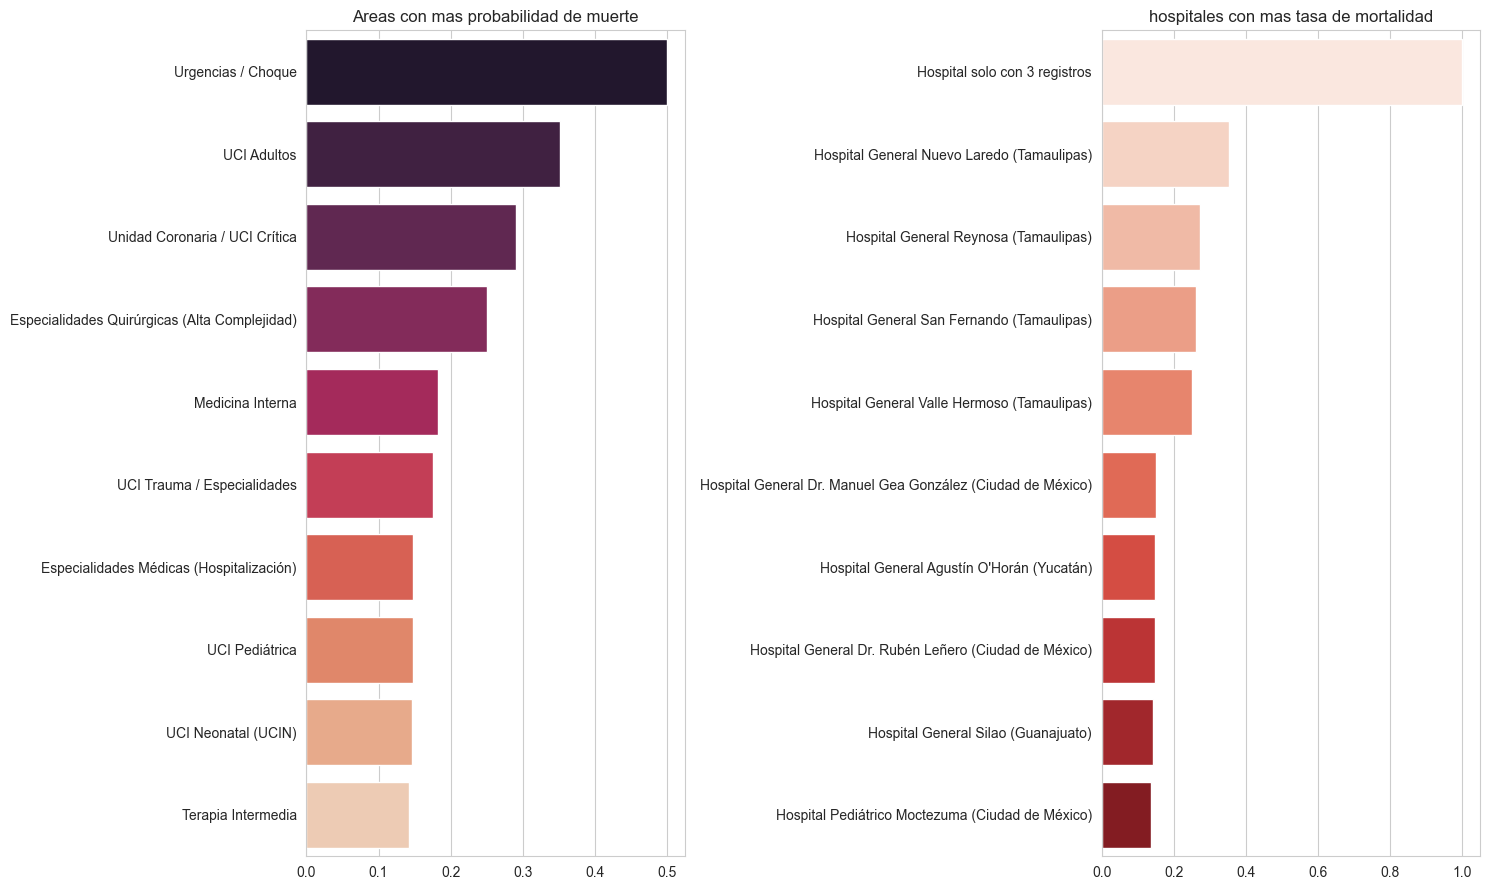

In [33]:
areas_top_10 = df.groupby('SERVICIOINGRE')['defuncion'].mean().sort_values(ascending=False).head(10)
egreso_top_10 =df.groupby('CLUES')['defuncion'].mean().sort_values(ascending=False).head(10)

fig,ax = plt.subplots(1,2,figsize = (15,9))
ax = ax.flat
ax[0].set_title('Areas con mas probabilidad de muerte')
sns.barplot(x=areas_top_10.values,y=[
    "Urgencias / Choque",
    "UCI Adultos",
    "Unidad Coronaria / UCI Crítica",
    "Especialidades Quirúrgicas (Alta Complejidad)",
    "Medicina Interna",
    "UCI Trauma / Especialidades",
    "Especialidades Médicas (Hospitalización)",
    "UCI Pediátrica",
    "UCI Neonatal (UCIN)",
    "Terapia Intermedia"
],palette='rocket',ax=ax[0])

ax[1].set_title('hospitales con mas tasa de mortalidad')
sns.barplot(x=egreso_top_10.values, y=[
    "Hospital solo con 3 registros",
    "Hospital General Nuevo Laredo (Tamaulipas)",
    "Hospital General Reynosa (Tamaulipas)",
    "Hospital General San Fernando (Tamaulipas)",
    "Hospital General Valle Hermoso (Tamaulipas)",
    "Hospital General Dr. Manuel Gea González (Ciudad de México)",
    "Hospital General Agustín O'Horán (Yucatán)",
    "Hospital General Dr. Rubén Leñero (Ciudad de México)",
    "Hospital General Silao (Guanajuato)",
    "Hospital Pediátrico Moctezuma (Ciudad de México)"
],orient='h',ax=ax[1],palette='Reds')

plt.tight_layout()
plt.show()

eliminaremos columnas que causan data_leakge

In [34]:
cols_eliminar = ['SERVICIOEGRE', 'DIAS_ESTA', 'SERVHP']
df = df.drop(columns=cols_eliminar)

In [35]:
df['MOTEGRE'].value_counts(normalize=True) * 100

MOTEGRE
2    88.200919
7     3.540570
5     2.538477
1     2.042660
3     1.876526
4     1.748751
6     0.052098
Name: proportion, dtype: float64

tenemos algo, si ven el 4 y 6 son casos sensurados, pero son pocos entonces podemos suponer que esos no fueron mortarles, osea lo dejamos fuera del area sin incluirlos

In [36]:
df['SERVICIO02'].unique()

array([ -1, 203, 201, 102, 113, 112, 115, 114, 103, 603, 311, 321, 802,
       599, 108, 403, 505, 517, 702, 214, 606, 701, 703, 104, 110, 501,
       116, 405, 211, 208, 105, 999, 107, 518, 205, 213, 210, 402, 301,
       339, 207, 310, 605, 512, 511, 322, 109, 510, 212, 331, 502, 323,
       106, 515, 313, 506, 316, 314, 317, 307, 204, 516, 326, 514, 304,
       309, 509, 327, 325, 308, 335, 318, 305, 315, 338, 319, 101, 111,
       209, 602, 901, 507, 312, 803, 306, 332, 302, 324, 303, 404, 333,
       117, 604, 337, 601, 202, 336, 513, 406, 330, 801])

In [37]:
print(df.groupby('SERVICIO02')['defuncion'].mean().sort_values(ascending = False).head(20))
print(df.groupby('SERVICIO03')['defuncion'].mean().sort_values(ascending = False).head(20))

SERVICIO02
333    0.666667
601    0.500000
606    0.287293
901    0.285714
103    0.252688
507    0.250000
110    0.240741
604    0.200000
518    0.200000
506    0.192771
327    0.189189
114    0.173913
106    0.173077
603    0.165038
107    0.140940
205    0.133929
102    0.129032
203    0.125000
116    0.123810
213    0.116992
Name: defuncion, dtype: float64
SERVICIO03
516    1.000000
204    1.000000
327    0.500000
203    0.400000
114    0.339623
106    0.333333
510    0.333333
210    0.333333
113    0.314286
201    0.306122
213    0.304348
109    0.300000
116    0.272727
115    0.263158
308    0.250000
511    0.222222
603    0.203125
207    0.200000
214    0.190476
205    0.187500
Name: defuncion, dtype: float64


In [38]:
print(df.groupby('SERVICIO02')['defuncion'].agg(['mean','count']).sort_values('mean', ascending=False).head(20))
print(df.groupby('SERVICIO03')['defuncion'].agg(['mean','count']).sort_values('mean', ascending=False).head(20))

                mean  count
SERVICIO02                 
333         0.666667      3
601         0.500000      2
606         0.287293    543
901         0.285714      7
103         0.252688    186
507         0.250000      8
110         0.240741    108
604         0.200000     10
518         0.200000      5
506         0.192771    249
327         0.189189     37
114         0.173913    207
106         0.173077     52
603         0.165038   3684
107         0.140940    149
205         0.133929    112
102         0.129032     62
203         0.125000     56
116         0.123810    105
213         0.116992    359
                mean  count
SERVICIO03                 
516         1.000000      1
204         1.000000      2
327         0.500000      2
203         0.400000      5
114         0.339623     53
106         0.333333      6
510         0.333333      9
210         0.333333      6
113         0.314286     35
201         0.306122     49
213         0.304348     23
109         0.300000

muchas tienen muestras pequenas y odria ser data leakge ya que es despues del diagnostico inicial, lo mueven y eso no se tiene al momento entrar

In [39]:
df.drop(['SERVICIO02','SERVICIO03'],axis=1,inplace=True)

# TRATAMIENTO DE CIE-10

In [40]:
cat_cie10 = pd.read_csv('../datos/CAT_CIE_10_2021.csv',encoding='latin-1',sep='|',usecols=['CLAVE', 'NOMBRE', 'CLAVE_CAPITULO', 'CAPITULO'])
cat_cie10 = cat_cie10.drop_duplicates(subset='CLAVE')

In [41]:
df_wcie = df.merge(
    cat_cie10[['CLAVE', 'CAPITULO']].rename(columns={'CAPITULO': 'capitulo_afecprin'}),
    left_on='AFECPRIN', right_on='CLAVE', how='left'
).drop(columns='CLAVE')

df_wcie = df_wcie.merge(
    cat_cie10[['CLAVE', 'CAPITULO']].rename(columns={'CAPITULO': 'capitulo_diag_ini'}),
    left_on='DIAG_INI', right_on='CLAVE', how='left'
).drop(columns='CLAVE')

df_wcie = df_wcie.merge(
    cat_cie10[['CLAVE', 'CAPITULO']].rename(columns={'CAPITULO': 'capitulo_causaext'}),
    left_on='CAUSAEXT', right_on='CLAVE', how='left'
).drop(columns='CLAVE')

In [42]:
df_wcie.columns

Index(['CLUES', 'EGRESO', 'INGRE', 'TUHPSIQ', 'SERVHC', 'CVEEDAD', 'EDAD',
       'NACIOEN', 'SEXO', 'PESO', 'TALLA', 'DERHAB', 'ENTIDAD', 'MUNIC', 'LOC',
       'INDIGENA', 'HABLA_LENGUA', 'LENGUA_INDIGENA', 'TIPSERV',
       'SERVICIOINGRE', 'PROCED', 'MOTEGRE', 'DIAG_INI', 'AFECPRIN', 'VEZ',
       'INFEC', 'CAUSAEXT', 'MES_ESTADISTICO', 'ESTADO_CONYUGAL_KEY',
       'defuncion', 'capitulo_afecprin', 'capitulo_diag_ini',
       'capitulo_causaext'],
      dtype='object')

eliminamos el crudo

In [43]:
df_wcie = df_wcie.drop(columns=['AFECPRIN', 'DIAG_INI', 'CAUSAEXT'])

# MODELADO

In [44]:
X = df_wcie.drop(['MOTEGRE','defuncion'],axis=1)
y = df_wcie['defuncion']

X_train,X_test,y_train,y_test = train_test_split(X,y, random_state=42, stratify=y) 

In [45]:
for col in X_train.select_dtypes(include=['object']).columns:
    X_train[col] = X_train[col].astype('category')
    X_test[col] = X_test[col].astype('category')

# optimizar modelo con optuna

In [46]:
def objetivo(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 1.0, 50.0),
        'enable_categorical': True,
        'tree_method': 'hist',
        'random_state': 42,
        'n_jobs' : -1
    }
    modelo = XGBClassifier(**params)
    score = cross_val_score(modelo, X_train, y_train, scoring='average_precision', cv=5,n_jobs=-1)
    return score.mean()

In [47]:
study = optuna.create_study(direction='maximize')

[I 2026-07-13 20:17:01,172] A new study created in memory with name: no-name-3049dd1f-5922-4212-b691-6558d57f3abd


In [ ]:
study.optimize(objetivo,n_trials=50,n_jobs=-1)